# Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position

## 1. Research Objective

Phase 2 tested a learned, position-aware plasticity rule on a *single* plastic layer (`fc3`).
Because only one layer was ever plastic, `layer_position` was constant — the experiment could
not actually test whether position *helps*, only whether the feature was harmless.

This notebook makes `fc2` plastic as well, so `layer_position` finally varies (`fc2 = 0.0`,
`fc3 = 1.0`), and asks:

* **RQ1** — Does training multiple layers improve learned-Hebbian performance?
* **RQ2** — Does `layer_position` become useful once it actually varies?
* **RQ3** — Can one shared `PlasticityNetwork` learn different update behavior per layer?
* **RQ4** — Does multi-layer learned Hebbian outperform conventional Hebbian?
* **RQ5** — Does the rule remain genuinely local (no backprop through the main plastic weights)?
* **RQ6** — Does training multiple layers expose a failure mode in the one-step meta-objective?

**Most important research principle (unchanged from Phase 2):** the goal is not to make learned
plasticity win — it's to find out whether the hypothesis is scientifically supported. Section 19
answers each RQ directly from the numbers this notebook actually produces, and Section 20 states
plainly where the evidence is negative.

## 2. Previous Experiment Summary

Verified directly from your executed `Learned_Hebbian_Plasticity_Phase2_Controlled.ipynb`
(`summary.csv` output, 3 seeds each):

| Method | Test acc (mean) | Final val loss (mean) | Plasticity params |
|---|---:|---:|---:|
| Backprop (fc1+fc2+fc3) | 82.57% | 0.447 | 0 |
| Conventional Hebbian (fc3 only) | 63.27% | 1.374 | 0 |
| Learned Hebbian, full features (fc3 only) | 11.60% | 2.845 | 801 |
| Learned Hebbian, all other ablations | 11-18% | 2.20-2.87 | 801 |

**A pattern worth carrying forward that the summary table alone doesn't show:** inspecting the
per-epoch prints, several learned-Hebbian seeds didn't merely train slowly — `val_loss` converged
to *exactly* `ln(10) ~= 2.3026` (e.g. `ablation_1_basic`, seed 42, epochs 5-15) — the loss value a
model gets from predicting a **perfectly uniform distribution over all 10 classes**. That's
consistent with `fc3.weight` collapsing toward all-near-zero rather than merely training slowly,
since a near-zero weight matrix produces near-identical logits for every input. Other seeds (e.g.
`ablation_1_basic`, seed 123) instead showed noisy, non-monotonic improvement — so the collapse
isn't universal, it's seed-dependent instability.

**Working hypothesis for this notebook to test (Section 15):** the one-step lookahead
meta-objective may have found "shrink the weight toward zero" as a low-risk, low-variance local
optimum — a myopic single step of cross-entropy loss doesn't have to see that repeatedly shrinking
the weight is a bad long-run policy. If true, this should show up as `weight_std` trending toward
0 over epochs, which we now log directly.

**Limitations already identified in Phase 2, still open:**
1. Only the final layer was ever plastic (fixed here - `fc2` is now plastic too).
2. `layer_position` was constant (fixed here - `fc2=0.0`, `fc3=1.0`).
3. Synapse features are batch-averaged (still true here - see Section 20).
4. The plasticity network is trained with a one-step lookahead only (still true here, but now
   diagnosed more directly - see Sections 9, 15).

## 3. Imports

In [1]:
import os
import json
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms


## 4. Configuration

Dataset, split, architecture widths, and default hyperparameters are **unchanged from Phase 2**
so results stay comparable. The only new items are the layer-position mapping and a *predefined*
learning-rate sensitivity grid (Section 15) - defined here, before any results exist, per the
"do not tune until it looks good" requirement.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# -----------------------------
# Dataset (identical to Phase 2)
# -----------------------------
DATASET = "FashionMNIST"
N_TRAIN = 5000
N_VAL = 1000
N_TEST = 1000
BATCH_SIZE = 64
DATA_SPLIT_SEED = 0

# -----------------------------
# Architecture (identical to Phase 2)
# -----------------------------
INPUT_DIM = 28 * 28
HIDDEN1 = 128
HIDDEN2 = 64
OUTPUT_DIM = 10

# -----------------------------
# Training (identical defaults to Phase 2 -- NOT retuned, see Section 20)
# -----------------------------
EPOCHS = 15
BACKPROP_LR = 1e-3
HEBBIAN_LR = 5e-2
PLASTICITY_LR = 5e-2
META_LR = 1e-3
GRAD_CLIP_NORM = 1.0  # new in Phase 3 (Section 15) -- Phase 2 had no clipping

SEEDS = [42, 123, 456, 789, 2024]  # 5 seeds, per the prompt's preference (runs are cheap here)

# -----------------------------
# Layer position mapping (Section 5 of the research prompt)
# -----------------------------
LAYER_POSITIONS = {"fc2": 0.0, "fc3": 1.0}

# -----------------------------
# Plasticity network (unchanged architecture from Phase 2)
# -----------------------------
FEATURE_NAMES = [
    "pre_activation", "post_activation", "weight", "local_error",
    "pre_position", "post_position", "layer_position",
]
PLASTICITY_HIDDEN1 = 32
PLASTICITY_HIDDEN2 = 16

# Feature masks -- this notebook's ablation targets layer_position specifically (Section 14),
# so only the last mask entry differs between the two primary multi-layer conditions.
WITH_LAYER_POSITION = [1, 1, 1, 1, 1, 1, 1]
WITHOUT_LAYER_POSITION = [1, 1, 1, 1, 1, 1, 0]

# -----------------------------
# Predefined LR sensitivity scan (Section 15) -- defined BEFORE seeing any results.
# Tests the "is plasticity_lr too large" question directly. Only applied to condition F
# (the primary two-layer + position condition), on a reduced seed set to control cost.
# -----------------------------
LR_SCAN_PLASTICITY_LR = [5e-2, 5e-3, 5e-4]  # 5e-2 == default, included as the control point
LR_SCAN_SEEDS = SEEDS[:3]

# -----------------------------
# Output
# -----------------------------
EXPERIMENT_NAME = "Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position"
LOCAL_OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", EXPERIMENT_NAME)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

S3_BUCKET = None  # e.g. "my-diffusion-hebbian-experiments"; None disables upload
S3_PREFIX = f"diffusion-hebbian/{EXPERIMENT_NAME}"

print(f"Output dir: {LOCAL_OUTPUT_DIR}")


Using device: cuda
Output dir: /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position


## 5. Dataset

Identical split logic to Phase 2 -- same seed, same sizes -- so results are directly comparable.

In [3]:
dataset_cls = datasets.FashionMNIST if DATASET == "FashionMNIST" else datasets.MNIST
transform = transforms.Compose([transforms.ToTensor()])

full_train = dataset_cls(root="./data", train=True, download=True, transform=transform)
full_test = dataset_cls(root="./data", train=False, download=True, transform=transform)

split_gen = torch.Generator().manual_seed(DATA_SPLIT_SEED)
train_idx = torch.randperm(len(full_train), generator=split_gen)[: N_TRAIN + N_VAL]
train_idx, val_idx = train_idx[:N_TRAIN], train_idx[N_TRAIN:]
test_idx = torch.randperm(len(full_test), generator=split_gen)[:N_TEST]

train_subset = torch.utils.data.Subset(full_train, train_idx)
val_subset = torch.utils.data.Subset(full_train, val_idx)
test_subset = torch.utils.data.Subset(full_test, test_idx)


def make_loader(subset, shuffle, seed=None):
    gen = torch.Generator().manual_seed(seed) if seed is not None else None
    return torch.utils.data.DataLoader(subset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=gen)


val_loader = make_loader(val_subset, shuffle=False)
test_loader = make_loader(test_subset, shuffle=False)

print(f"Dataset: {DATASET} | train={len(train_subset)} val={len(val_subset)} test={len(test_subset)}")


Dataset: FashionMNIST | train=5000 val=1000 test=1000


## 6. Model Architecture

Same `784 -> 128 -> 64 -> 10` shape as Phase 2. Two changes:

* `forward()` now also returns `h1` (the frozen `fc1`'s output), since `fc2` is plastic in this
  notebook and needs its own pre-synaptic activation.
* `fc2` now has **no bias** (`bias=False`), matching `fc3`'s existing convention -- a plastic
  layer's bias would otherwise sit outside the entire feature/update framework, untouched by any
  rule, which would be an unprincipled inconsistency once `fc2` becomes plastic.

`fc1` is always frozen at random initialization in every condition except the backprop baseline --
this notebook keeps that Phase-2 precedent to keep the experiment controlled, per the research
prompt's explicit instruction.

In [4]:
class SmallMLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden1=HIDDEN1, hidden2=HIDDEN2, output_dim=OUTPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)              # always frozen (random feature extractor)
        self.fc2 = nn.Linear(hidden1, hidden2, bias=False)     # plastic in multi-layer conditions
        self.fc3 = nn.Linear(hidden2, output_dim, bias=False)  # plastic in every non-backprop condition

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        logits = self.fc3(h2)
        return logits, h1, h2


def set_requires_grad(model, layer_names, flag):
    for name in layer_names:
        for p in getattr(model, name).parameters():
            p.requires_grad_(flag)


def param_count(module):
    return sum(p.numel() for p in module.parameters())


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _, _ = model(x)
        total_loss += F.cross_entropy(logits, y, reduction="sum").item()
        correct += (logits.argmax(dim=-1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


## 7. Conventional Hebbian Rule

Math unchanged from Phase 2 (itself unchanged from the original diffusion notebook's `hebbian_conv_update`). Now returns the raw update tensor as well, for diagnostics, and generalized to apply to an arbitrary set of layers via `MultiLayerHebbianRule`.

In [5]:
def hebbian_linear_update(layer, pre_activation, error, learning_rate):
    update = torch.einsum("bo,bi->oi", error, pre_activation) / pre_activation.size(0)
    update = update / (update.norm() + 1e-8)

    assert torch.isfinite(update).all(), "Non-finite Hebbian update"

    with torch.no_grad():
        layer.weight.add_(learning_rate * update)

    return update.detach()


class MultiLayerHebbianRule:
    """Baseline B/C -- conventional Hebbian, applied to one or more layers independently."""

    def __init__(self, learning_rate, layer_specs):
        # layer_specs: {name: {"layer": nn.Linear}}
        self.learning_rate = learning_rate
        self.layer_specs = layer_specs

    def apply(self, activations, errors):
        diagnostics = {}
        for name, spec in self.layer_specs.items():
            layer = spec["layer"]
            pre, _post = activations[name]
            error = errors[name]
            update = hebbian_linear_update(layer, pre.detach(), error.detach(), self.learning_rate)
            diagnostics[name] = {"delta_w": update, "meta_loss": None}
        return diagnostics


## 8. Plasticity Network

Architecture unchanged from Phase 2 -- small, shared, evaluated on every synapse in a single batched call.

In [6]:
class PlasticityNetwork(nn.Module):
    def __init__(self, feature_dim=len(FEATURE_NAMES), hidden1=PLASTICITY_HIDDEN1, hidden2=PLASTICITY_HIDDEN2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.Linear(hidden2, 1),
        )

    def forward(self, features):
        return self.net(features).squeeze(-1)


def build_synapse_features(pre_activation, post_activation, weight, local_error, layer_position, feature_mask=None):
    """Unchanged from Phase 2 -- batch-mean aggregation, broadcast to every (i, j) synapse,
    vectorized (no Python loop over weights). See Section 20 for the batch-averaging caveat."""
    out_features, in_features = weight.shape
    dev = weight.device

    pre_mean = pre_activation.mean(dim=0)
    post_mean = post_activation.mean(dim=0)
    error_mean = local_error.mean(dim=0) if local_error is not None else torch.zeros(out_features, device=dev)

    pre_pos = torch.linspace(0, 1, in_features, device=dev) if in_features > 1 else torch.zeros(in_features, device=dev)
    post_pos = torch.linspace(0, 1, out_features, device=dev) if out_features > 1 else torch.zeros(out_features, device=dev)

    pre_grid = pre_mean.unsqueeze(0).expand(out_features, in_features)
    post_grid = post_mean.unsqueeze(1).expand(out_features, in_features)
    error_grid = error_mean.unsqueeze(1).expand(out_features, in_features)
    weight_grid = weight
    pre_pos_grid = pre_pos.unsqueeze(0).expand(out_features, in_features)
    post_pos_grid = post_pos.unsqueeze(1).expand(out_features, in_features)
    layer_pos_grid = torch.full((out_features, in_features), float(layer_position), device=dev)

    features = torch.stack(
        [pre_grid, post_grid, weight_grid, error_grid, pre_pos_grid, post_pos_grid, layer_pos_grid],
        dim=-1,
    )

    if feature_mask is not None:
        mask = torch.tensor(feature_mask, dtype=features.dtype, device=dev)
        features = features * mask

    return features.view(-1, len(FEATURE_NAMES)), (out_features, in_features)


## 9. Multi-Layer Learned Hebbian Rule

Generalizes Phase 2's single-layer rule to an arbitrary set of plastic layers, all routed through
**one shared `PlasticityNetwork`** (never one network per layer, per the prompt's constraint).

**Locality (RQ5), concretely enforced, not just asserted in prose:**
* `fc1`, `fc2`, `fc3` all have `requires_grad_(False)` whenever this rule is used -- `.backward()`
  can never populate their `.grad`, by construction, regardless of what any loss elsewhere does.
* The main-network update is always `layer.weight.copy_(original_weight + lr * delta_w.detach())`
  inside `torch.no_grad()` -- a plain tensor write, not an optimizer step on a loss.
* `assert layer.weight.grad is None` runs after every update as a live check, not a one-time
  claim, so a future refactor that accidentally reintroduces `requires_grad=True` would fail loudly.

**Meta-training the shared network (theta), one layer at a time, one-step lookahead:**
* For `fc3` (the last layer): `logits_lookahead = F.linear(h2, W_fc3 + lr*dw_fc3)`, loss against
  the true label -- identical in spirit to Phase 2.
* For `fc2` (an intermediate layer): its effect on the task loss only exists *after* going through
  `fc3`, so the lookahead must forward through `fc3` too:
  `logits_lookahead = F.linear(relu(F.linear(h1, W_fc2 + lr*dw_fc2)), W_fc3_current)`, using
  `fc3`'s *current, detached* weight -- i.e. "if only `fc2` changed, holding everything else fixed,
  would the task loss go down?" `h1`, `h2`, and `W_fc3_current` are all detached constants; the
  only tensor requiring grad in either lookahead is theta, reached through `delta_w`.
* Both layers update the **same** shared theta in the same batch (`fc2`'s meta-step first, then
  `fc3`'s) -- this is a deliberate design choice, not an oversight; see Section 20 for the
  simultaneous-vs-sequential-update discussion the prompt specifically asked to consider.

Gradient clipping (`GRAD_CLIP_NORM`) on theta's meta-gradient is new in this notebook -- Phase 2
had none; it's applied here from the start (not added reactively) as a standard stabilizer for a
meta-learning signal, consistent with Section 14's stability guidance.

In [7]:
class MultiLayerLearnedHebbianRule:
    def __init__(self, plasticity_net, plasticity_lr, meta_optimizer, layer_specs, grad_clip_norm=GRAD_CLIP_NORM):
        # layer_specs: ordered dict name -> {"layer": nn.Linear, "layer_position": float, "feature_mask": list}
        assert all(p.requires_grad for p in plasticity_net.parameters()), \
            "PlasticityNetwork params must be trainable"
        self.plasticity_net = plasticity_net
        self.plasticity_lr = plasticity_lr
        self.meta_optimizer = meta_optimizer
        self.layer_specs = layer_specs
        self.grad_clip_norm = grad_clip_norm

    def _lookahead_logits(self, name, pre, w_lookahead):
        if name == "fc3":
            return F.linear(pre, w_lookahead)  # pre == h2 (detached)
        elif name == "fc2":
            h2_lookahead = F.relu(F.linear(pre, w_lookahead))  # pre == h1 (detached)
            fc3_weight = self.layer_specs["fc3"]["layer"].weight.detach()
            return F.linear(h2_lookahead, fc3_weight)
        else:
            raise ValueError(f"No lookahead path defined for layer '{name}'")

    def apply(self, activations, errors, target, train_plasticity_net=True):
        diagnostics = {}

        for name, spec in self.layer_specs.items():
            layer = spec["layer"]
            pre, post = activations[name]
            error = errors[name]

            original_weight = layer.weight.detach().clone()  # snapshot BEFORE any update

            features, shape = build_synapse_features(
                pre.detach(), post.detach(), original_weight,
                error.detach(), spec["layer_position"], spec["feature_mask"],
            )
            delta_w = self.plasticity_net(features).view(*shape)
            assert torch.isfinite(delta_w).all(), f"Non-finite learned Hebbian update at '{name}'"

            # --- Main network update: plain tensor write, never loss.backward() ---
            with torch.no_grad():
                layer.weight.copy_(original_weight + self.plasticity_lr * delta_w.detach())
            assert layer.weight.grad is None, f"Locality violated: '{name}'.weight.grad is not None"

            meta_loss_value = None
            if train_plasticity_net:
                self.meta_optimizer.zero_grad()
                w_lookahead = original_weight + self.plasticity_lr * delta_w
                logits_lookahead = self._lookahead_logits(name, pre.detach(), w_lookahead)
                meta_loss = F.cross_entropy(logits_lookahead, target)
                meta_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.plasticity_net.parameters(), self.grad_clip_norm)
                self.meta_optimizer.step()
                meta_loss_value = meta_loss.item()

            diagnostics[name] = {"delta_w": delta_w.detach(), "meta_loss": meta_loss_value}

        return diagnostics


## 10. Local Error Signals

`fc3`'s local error is unchanged from Phase 2: `target_one_hot - softmax(logits)` -- this is
already fully local (only needs this layer's own output and the true label).

**`fc2` needs a genuinely different treatment.** `target_one_hot - softmax(logits)` uses `logits`,
which is `fc3`'s output -- reading it for `fc2`'s error would smuggle in `fc3`'s (and therefore
downstream) information, and taking it further (e.g. multiplying by `fc3`'s weight matrix, as
backprop's chain rule would) is exactly the kind of "disallowed global information" the research
prompt rules out.

**Design decision:** `fc2` gets a **fixed, non-trained random auxiliary readout** -- a technique
used in the local/greedy learning literature to give an intermediate layer its own local
classification signal without any gradient from later layers:

```
R = fixed random matrix, shape [hidden2, output_dim], generated once at model init, never trained
aux_logits = h2 @ R
error_fc2_aux = target_one_hot - softmax(aux_logits)         # local error in the AUXILIARY 10-dim space
error_fc2 = error_fc2_aux @ R.T                                # projected back into fc2's own 64-dim output space
```

This only ever touches `h2` (this layer's own output), `R` (a fixed random matrix that has nothing
to do with `fc3`'s weights), and the true label -- never `fc3`'s weights, output, or gradient.

**Explicit limitation:** `R` is random and untrained, so `error_fc2` is a noisy, weak proxy for
"what would actually help the final classification" -- there's no guarantee a random projection of
`h2` preserves much class-relevant structure, especially since `fc1` is also frozen-random. If
`fc2`'s learned-Hebbian condition underperforms, this proxy is one of the first places to look
before concluding anything about `layer_position` itself (see Section 20).

In [8]:
def make_auxiliary_projection(hidden_dim, output_dim, seed):
    gen = torch.Generator().manual_seed(seed)
    R = torch.randn(hidden_dim, output_dim, generator=gen)
    R = R / R.norm()
    return R  # fixed, never trained; caller moves it to device


def compute_local_errors(model, x, target_one_hot, aux_projection):
    with torch.no_grad():
        logits, h1, h2 = model(x)

    error_fc3 = target_one_hot - F.softmax(logits, dim=-1)

    aux_logits = h2 @ aux_projection
    error_fc2_aux = target_one_hot - F.softmax(aux_logits, dim=-1)
    error_fc2 = error_fc2_aux @ aux_projection.t()

    errors = {"fc2": error_fc2, "fc3": error_fc3}
    activations = {"fc2": (h1, h2), "fc3": (h2, logits)}
    return errors, activations, logits


## 11. Experiment Runner

One function drives every condition (A-F), so all six are directly comparable. Per-epoch
diagnostics (update magnitude, weight statistics, plasticity-network meta-loss) are collected for
every plastic layer, satisfying Section 15's requirements without a separate code path.

In [9]:
class BackpropTrainer:
    def __init__(self, model, lr):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self, x, target):
        self.optimizer.zero_grad()
        logits, _, _ = self.model(x)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        self.optimizer.step()
        return loss.item()


class MetricsLogger:
    def __init__(self):
        self.records = []

    def log(self, record):
        self.records.append(record)

    def to_dataframe(self):
        return pd.DataFrame(self.records)

    def save(self, path):
        self.to_dataframe().to_csv(path, index=False)


def run_condition(condition_name, method, plastic_layers, seed, feature_mask_map=None,
                   plasticity_lr=None, epochs=EPOCHS, return_artifacts=False):
    """method: 'backprop' | 'hebbian' | 'learned_hebbian'
    plastic_layers: e.g. ['fc3'] or ['fc2', 'fc3'] (order matters: fc2 before fc3)
    Returns (result_dict, artifacts_or_None). artifacts holds live model/rule objects for
    diagnostics that need to query the trained network after the fact (Section 16) -- never
    JSON-serialized.
    """
    plasticity_lr = PLASTICITY_LR if plasticity_lr is None else plasticity_lr

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SmallMLP().to(device)
    train_loader = make_loader(train_subset, shuffle=True, seed=seed)

    trainable_params = param_count(model)
    plasticity_params = 0
    plasticity_net = None
    aux_projection = None
    layer_map = {"fc2": model.fc2, "fc3": model.fc3}

    diag_history = {name: {"update_mean_abs": [], "update_std": [], "update_max": [],
                            "weight_mean": [], "weight_std": [], "weight_min": [], "weight_max": [],
                            "meta_loss": []}
                     for name in (plastic_layers if method != "backprop" else [])}

    if method == "backprop":
        trainer = BackpropTrainer(model, BACKPROP_LR)
    else:
        set_requires_grad(model, ["fc1", "fc2", "fc3"], False)
        trainable_params = 0
        aux_projection = make_auxiliary_projection(HIDDEN2, OUTPUT_DIM, seed + 10_000).to(device)

        if method == "hebbian":
            layer_specs = {name: {"layer": layer_map[name]} for name in plastic_layers}
            rule = MultiLayerHebbianRule(HEBBIAN_LR, layer_specs)
        elif method == "learned_hebbian":
            plasticity_net = PlasticityNetwork().to(device)
            plasticity_params = param_count(plasticity_net)
            meta_optimizer = torch.optim.Adam(plasticity_net.parameters(), lr=META_LR)
            layer_specs = {
                name: {
                    "layer": layer_map[name],
                    "layer_position": LAYER_POSITIONS[name] if len(plastic_layers) > 1 else 1.0,
                    "feature_mask": (feature_mask_map[name] if feature_mask_map else WITH_LAYER_POSITION),
                }
                for name in plastic_layers
            }
            rule = MultiLayerLearnedHebbianRule(plasticity_net, plasticity_lr, meta_optimizer, layer_specs)
        else:
            raise ValueError(f"Unknown method: {method}")

    train_loss_history, val_loss_history, val_acc_history = [], [], []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss, n = 0.0, 0
        epoch_diag = {name: {"abs_mean": [], "std": [], "max": [], "meta_loss": []} for name in diag_history}

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            target_one_hot = F.one_hot(y, num_classes=OUTPUT_DIM).float()

            if method == "backprop":
                loss = trainer.step(x, y)
            else:
                errors, activations, logits = compute_local_errors(model, x, target_one_hot, aux_projection)
                activations = {name: activations[name] for name in plastic_layers}
                errors = {name: errors[name] for name in plastic_layers}
                loss = F.cross_entropy(logits, y).item()  # logged only, never backpropped

                if method == "hebbian":
                    diag = rule.apply(activations, errors)
                else:
                    diag = rule.apply(activations, errors, y)

                for name in plastic_layers:
                    dw = diag[name]["delta_w"]
                    epoch_diag[name]["abs_mean"].append(dw.abs().mean().item())
                    epoch_diag[name]["std"].append(dw.std().item())
                    epoch_diag[name]["max"].append(dw.abs().max().item())
                    ml = diag[name].get("meta_loss")
                    if ml is not None:
                        epoch_diag[name]["meta_loss"].append(ml)

            total_loss += loss * x.size(0)
            n += x.size(0)

        train_loss = total_loss / n
        val_loss, val_acc = evaluate(model, val_loader)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        for name in diag_history:
            w = layer_map[name].weight.detach()
            d = diag_history[name]
            e = epoch_diag[name]
            d["update_mean_abs"].append(float(np.mean(e["abs_mean"])) if e["abs_mean"] else float("nan"))
            d["update_std"].append(float(np.mean(e["std"])) if e["std"] else float("nan"))
            d["update_max"].append(float(np.max(e["max"])) if e["max"] else float("nan"))
            d["weight_mean"].append(w.mean().item())
            d["weight_std"].append(w.std().item())
            d["weight_min"].append(w.min().item())
            d["weight_max"].append(w.max().item())
            d["meta_loss"].append(float(np.mean(e["meta_loss"])) if e["meta_loss"] else float("nan"))

        print(f"[{condition_name} | seed={seed}] Epoch [{epoch+1}/{epochs}] "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    train_time = time.time() - start
    test_loss, test_acc = evaluate(model, test_loader)

    result = {
        "condition": condition_name, "method": method, "seed": seed,
        "plastic_layers": plastic_layers, "plasticity_lr": plasticity_lr,
        "train_loss_history": train_loss_history, "val_loss_history": val_loss_history,
        "val_acc_history": val_acc_history,
        "final_train_loss": train_loss_history[-1], "final_val_loss": val_loss_history[-1],
        "best_val_loss": min(val_loss_history), "test_loss": test_loss, "test_acc": test_acc,
        "train_time_sec": train_time, "trainable_params": trainable_params,
        "plasticity_params": plasticity_params, "diagnostics": diag_history,
    }

    artifacts = None
    if return_artifacts:
        artifacts = {"model": model, "layer_map": layer_map, "aux_projection": aux_projection,
                     "plasticity_net": plasticity_net}

    return result, artifacts


logger = MetricsLogger()
all_results = []
condition_f_artifacts = None  # populated in Section 14, used in Section 16


## 12. Baseline Experiments

**A** -- full backprop baseline. **B** -- conventional Hebbian, `fc3` only (direct replication of Phase 2's baseline, same architecture).

In [10]:
for seed in SEEDS:
    r, _ = run_condition("A_backprop", "backprop", [], seed)
    all_results.append(r)

for seed in SEEDS:
    r, _ = run_condition("B_hebbian_single", "hebbian", ["fc3"], seed)
    all_results.append(r)


[A_backprop | seed=42] Epoch [1/15] train_loss=1.1765 val_loss=0.7691 val_acc=0.7100
[A_backprop | seed=42] Epoch [2/15] train_loss=0.6643 val_loss=0.6382 val_acc=0.7630
[A_backprop | seed=42] Epoch [3/15] train_loss=0.5626 val_loss=0.5453 val_acc=0.7940
[A_backprop | seed=42] Epoch [4/15] train_loss=0.5050 val_loss=0.4957 val_acc=0.8100
[A_backprop | seed=42] Epoch [5/15] train_loss=0.4809 val_loss=0.4953 val_acc=0.8220
[A_backprop | seed=42] Epoch [6/15] train_loss=0.4381 val_loss=0.4518 val_acc=0.8430
[A_backprop | seed=42] Epoch [7/15] train_loss=0.4210 val_loss=0.4609 val_acc=0.8190
[A_backprop | seed=42] Epoch [8/15] train_loss=0.4014 val_loss=0.4491 val_acc=0.8370
[A_backprop | seed=42] Epoch [9/15] train_loss=0.3997 val_loss=0.4386 val_acc=0.8370
[A_backprop | seed=42] Epoch [10/15] train_loss=0.3586 val_loss=0.4309 val_acc=0.8520
[A_backprop | seed=42] Epoch [11/15] train_loss=0.3531 val_loss=0.4760 val_acc=0.8270
[A_backprop | seed=42] Epoch [12/15] train_loss=0.3396 val_loss

## 13. Multi-Layer Experiments

**C** -- conventional Hebbian on `fc2`+`fc3`. **D** -- learned Hebbian, `fc3` only (regression/control condition, replicating Phase 2's `ablation_4_full` through this notebook's own generalized infrastructure).

In [11]:
for seed in SEEDS:
    r, _ = run_condition("C_hebbian_two_layer", "hebbian", ["fc2", "fc3"], seed)
    all_results.append(r)

for seed in SEEDS:
    r, _ = run_condition("D_learned_hebbian_single", "learned_hebbian", ["fc3"], seed,
                          feature_mask_map={"fc3": WITH_LAYER_POSITION})
    all_results.append(r)


[C_hebbian_two_layer | seed=42] Epoch [1/15] train_loss=2.1981 val_loss=2.0392 val_acc=0.3530
[C_hebbian_two_layer | seed=42] Epoch [2/15] train_loss=1.8344 val_loss=1.6086 val_acc=0.5570
[C_hebbian_two_layer | seed=42] Epoch [3/15] train_loss=1.4357 val_loss=1.2836 val_acc=0.5850
[C_hebbian_two_layer | seed=42] Epoch [4/15] train_loss=1.1748 val_loss=1.0952 val_acc=0.6020
[C_hebbian_two_layer | seed=42] Epoch [5/15] train_loss=1.0312 val_loss=0.9909 val_acc=0.6160
[C_hebbian_two_layer | seed=42] Epoch [6/15] train_loss=0.9595 val_loss=0.9426 val_acc=0.6060
[C_hebbian_two_layer | seed=42] Epoch [7/15] train_loss=0.9161 val_loss=0.9090 val_acc=0.6310
[C_hebbian_two_layer | seed=42] Epoch [8/15] train_loss=0.8847 val_loss=0.8765 val_acc=0.6440
[C_hebbian_two_layer | seed=42] Epoch [9/15] train_loss=0.8627 val_loss=0.8530 val_acc=0.6490
[C_hebbian_two_layer | seed=42] Epoch [10/15] train_loss=0.8393 val_loss=0.8567 val_acc=0.6430
[C_hebbian_two_layer | seed=42] Epoch [11/15] train_loss=0.

## 14. Position Ablation

**E vs F is the primary experiment.** Both train `fc2`+`fc3` with the learned rule, identical
dataset split / architecture / seeds / learning rates / plasticity-network architecture / epochs /
batch size -- the *only* difference is whether `layer_position` reaches the plasticity network
(`WITHOUT_LAYER_POSITION` zeroes that one feature; every other feature, including *within-layer*
`pre_position`/`post_position`, stays on for both).

Also runs the predefined LR sensitivity scan (Section 4) on condition F only, to directly test
whether `PLASTICITY_LR` being too large is contributing to instability -- reported as a separate,
clearly-labeled diagnostic, not used to cherry-pick a different headline number for F.

In [12]:
for seed in SEEDS:
    r, _ = run_condition("E_learned_two_layer_no_position", "learned_hebbian", ["fc2", "fc3"], seed,
                          feature_mask_map={"fc2": WITHOUT_LAYER_POSITION, "fc3": WITHOUT_LAYER_POSITION})
    all_results.append(r)

for seed in SEEDS:
    return_artifacts = (seed == SEEDS[0])
    r, artifacts = run_condition("F_learned_two_layer_with_position", "learned_hebbian", ["fc2", "fc3"], seed,
                                  feature_mask_map={"fc2": WITH_LAYER_POSITION, "fc3": WITH_LAYER_POSITION},
                                  return_artifacts=return_artifacts)
    all_results.append(r)
    if return_artifacts:
        condition_f_artifacts = artifacts


[E_learned_two_layer_no_position | seed=42] Epoch [1/15] train_loss=2.3195 val_loss=2.3127 val_acc=0.0970
[E_learned_two_layer_no_position | seed=42] Epoch [2/15] train_loss=2.2979 val_loss=2.3093 val_acc=0.1480
[E_learned_two_layer_no_position | seed=42] Epoch [3/15] train_loss=2.2994 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [4/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [5/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [6/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [7/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [8/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Epoch [9/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[E_learned_two_layer_no_position | seed=42] Ep

In [13]:
# --- LR sensitivity scan (predefined grid, Section 4) ---
lr_scan_results = []

for plasticity_lr in LR_SCAN_PLASTICITY_LR:
    for seed in LR_SCAN_SEEDS:
        r, _ = run_condition(f"F_lr_scan_plr={plasticity_lr}", "learned_hebbian", ["fc2", "fc3"], seed,
                              feature_mask_map={"fc2": WITH_LAYER_POSITION, "fc3": WITH_LAYER_POSITION},
                              plasticity_lr=plasticity_lr)
        lr_scan_results.append(r)

lr_scan_rows = []
by_plr = {}
for r in lr_scan_results:
    by_plr.setdefault(r["plasticity_lr"], []).append(r)

for plr, runs in sorted(by_plr.items()):
    lr_scan_rows.append({
        "plasticity_lr": plr,
        "final val loss (mean)": np.mean([r["final_val_loss"] for r in runs]),
        "final val loss (std)": np.std([r["final_val_loss"] for r in runs]),
        "test acc (mean)": np.mean([r["test_acc"] for r in runs]),
        "test acc (std)": np.std([r["test_acc"] for r in runs]),
        "fc3 final weight_std (mean)": np.mean([r["diagnostics"]["fc3"]["weight_std"][-1] for r in runs]),
    })

lr_scan_df = pd.DataFrame(lr_scan_rows)
print("LR sensitivity scan (condition F, reduced seed set) -- is plasticity_lr too large?")
lr_scan_df


[F_lr_scan_plr=0.05 | seed=42] Epoch [1/15] train_loss=2.3106 val_loss=2.3119 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [2/15] train_loss=2.3107 val_loss=2.5928 val_acc=0.1370
[F_lr_scan_plr=0.05 | seed=42] Epoch [3/15] train_loss=2.3064 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [4/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [5/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [6/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [7/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [8/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [9/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [10/15] train_loss=2.3026 val_loss=2.3026 val_acc=0.1030
[F_lr_scan_plr=0.05 | seed=42] Epoch [11/15] train_loss=2.3026 val_lo

,plasticity_lr,final val loss (mean),final val loss (std),test acc (mean),test acc (std),fc3 final weight_std (mean)
0,0.0005,2.302585,0.0,0.099,1.387779e-17,0.175605
1,0.0050,2.302585,0.0,0.099,1.387779e-17,0.203119
2,0.0500,2.302585,0.0,0.099,1.387779e-17,5.647262


## 15. Stability Diagnostics

Tests the collapse hypothesis from Section 2 directly: if `fc3.weight` is shrinking toward zero,
`weight_std` should trend downward over epochs for the learned-Hebbian conditions, and
`update_mean_abs` should either vanish (near-zero updates) or stay large while `weight_std` still
shrinks (i.e. the updates are directionally biased toward shrinkage rather than just small).

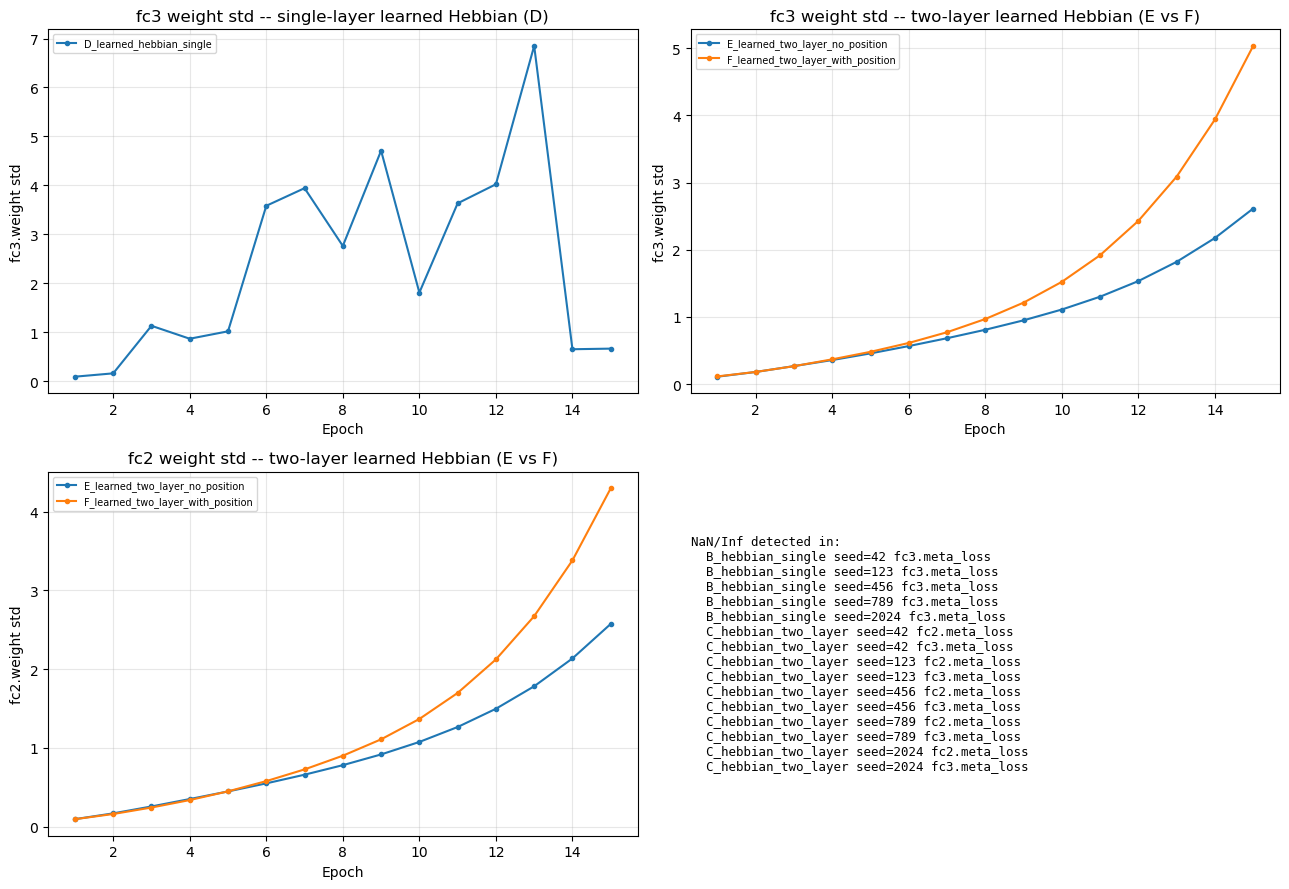

Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/update_distributions.png
NaN/Inf detected in:
  B_hebbian_single seed=42 fc3.meta_loss
  B_hebbian_single seed=123 fc3.meta_loss
  B_hebbian_single seed=456 fc3.meta_loss
  B_hebbian_single seed=789 fc3.meta_loss
  B_hebbian_single seed=2024 fc3.meta_loss
  C_hebbian_two_layer seed=42 fc2.meta_loss
  C_hebbian_two_layer seed=42 fc3.meta_loss
  C_hebbian_two_layer seed=123 fc2.meta_loss
  C_hebbian_two_layer seed=123 fc3.meta_loss
  C_hebbian_two_layer seed=456 fc2.meta_loss
  C_hebbian_two_layer seed=456 fc3.meta_loss
  C_hebbian_two_layer seed=789 fc2.meta_loss
  C_hebbian_two_layer seed=789 fc3.meta_loss
  C_hebbian_two_layer seed=2024 fc2.meta_loss
  C_hebbian_two_layer seed=2024 fc3.meta_loss


In [14]:
def plot_stability(results, condition_names, layer_name, title, ax):
    for cond in condition_names:
        runs = [r for r in results if r["condition"] == cond and layer_name in r["diagnostics"]]
        if not runs:
            continue
        weight_std_curves = np.array([r["diagnostics"][layer_name]["weight_std"] for r in runs])
        mean_curve = weight_std_curves.mean(axis=0)
        ax.plot(range(1, len(mean_curve) + 1), mean_curve, marker="o", markersize=3, label=cond)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"{layer_name}.weight std")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_stability(all_results, ["D_learned_hebbian_single"], "fc3", "fc3 weight std -- single-layer learned Hebbian (D)", axes[0, 0])
plot_stability(all_results, ["E_learned_two_layer_no_position", "F_learned_two_layer_with_position"], "fc3",
               "fc3 weight std -- two-layer learned Hebbian (E vs F)", axes[0, 1])
plot_stability(all_results, ["E_learned_two_layer_no_position", "F_learned_two_layer_with_position"], "fc2",
               "fc2 weight std -- two-layer learned Hebbian (E vs F)", axes[1, 0])

# NaN / Inf sweep across every logged diagnostic value
nan_flags = []
for r in all_results:
    for layer_name, d in r["diagnostics"].items():
        for key, series in d.items():
            arr = np.array(series, dtype=float)
            if np.isnan(arr).any() or np.isinf(arr).any():
                nan_flags.append((r["condition"], r["seed"], layer_name, key))

axes[1, 1].axis("off")
nan_text = "No NaN/Inf detected in any logged diagnostic." if not nan_flags else \
    "NaN/Inf detected in:\n" + "\n".join(f"  {c} seed={s} {l}.{k}" for c, s, l, k in nan_flags[:15])
axes[1, 1].text(0.0, 0.5, nan_text, fontsize=9, va="center", family="monospace")

plt.tight_layout()
update_dist_path = os.path.join(LOCAL_OUTPUT_DIR, "update_distributions.png")
plt.savefig(update_dist_path, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved {update_dist_path}")
print(nan_text)


In [15]:
# Weight and update statistics tables (Section 17 output files)
weight_rows, update_rows = [], []

for r in all_results:
    for layer_name, d in r["diagnostics"].items():
        weight_rows.append({
            "condition": r["condition"], "seed": r["seed"], "layer": layer_name,
            "final_weight_mean": d["weight_mean"][-1], "final_weight_std": d["weight_std"][-1],
            "final_weight_min": d["weight_min"][-1], "final_weight_max": d["weight_max"][-1],
            "initial_weight_std": d["weight_std"][0],
        })
        update_rows.append({
            "condition": r["condition"], "seed": r["seed"], "layer": layer_name,
            "mean_update_mean_abs": float(np.nanmean(d["update_mean_abs"])),
            "mean_update_std": float(np.nanmean(d["update_std"])),
            "max_update_max": float(np.nanmax(d["update_max"])) if d["update_max"] else float("nan"),
            "mean_meta_loss": float(np.nanmean(d["meta_loss"])) if any(not np.isnan(x) for x in d["meta_loss"]) else None,
        })

weight_stats_df = pd.DataFrame(weight_rows)
update_stats_df = pd.DataFrame(update_rows)

weight_stats_path = os.path.join(LOCAL_OUTPUT_DIR, "weight_statistics.csv")
update_stats_path = os.path.join(LOCAL_OUTPUT_DIR, "update_statistics.csv")
weight_stats_df.to_csv(weight_stats_path, index=False)
update_stats_df.to_csv(update_stats_path, index=False)

print(f"Saved {weight_stats_path} and {update_stats_path}")
weight_stats_df.groupby("condition")[["final_weight_std", "initial_weight_std"]].mean()


Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/weight_statistics.csv and /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/update_statistics.csv


,final_weight_std,initial_weight_std
condition,,
B_hebbian_single,1.101690,0.117918
C_hebbian_two_layer,0.323845,0.086016
D_learned_hebbian_single,0.669518,0.096819
E_learned_two_layer_no_position,2.594157,0.102172
F_learned_two_layer_with_position,4.666217,0.103969


## 16. Layer-Specific Update Analysis

Two diagnostics, both using the trained condition-F plasticity network from `condition_f_artifacts`
(seed `SEEDS[0]`):

1. **Position sensitivity** -- hold a representative synapse feature fixed and sweep
   `layer_position` from 0 to 1 continuously, plotting the network's predicted `delta_w`. If the
   network never learned to use position, this curve should be flat.
2. **fc2 vs. fc3 update distributions** -- `fc2` is `[64, 128]` and `fc3` is `[10, 64]`, so a raw
   element-wise correlation between them is meaningless (different shapes, different synapse
   counts). Instead we compare their `delta_w` **distributions** (histograms + summary statistics) at
   the end of training, and rely on the position-sensitivity curve above -- not a shape-mismatched
   correlation -- to answer whether the shared network conditions its output on position.

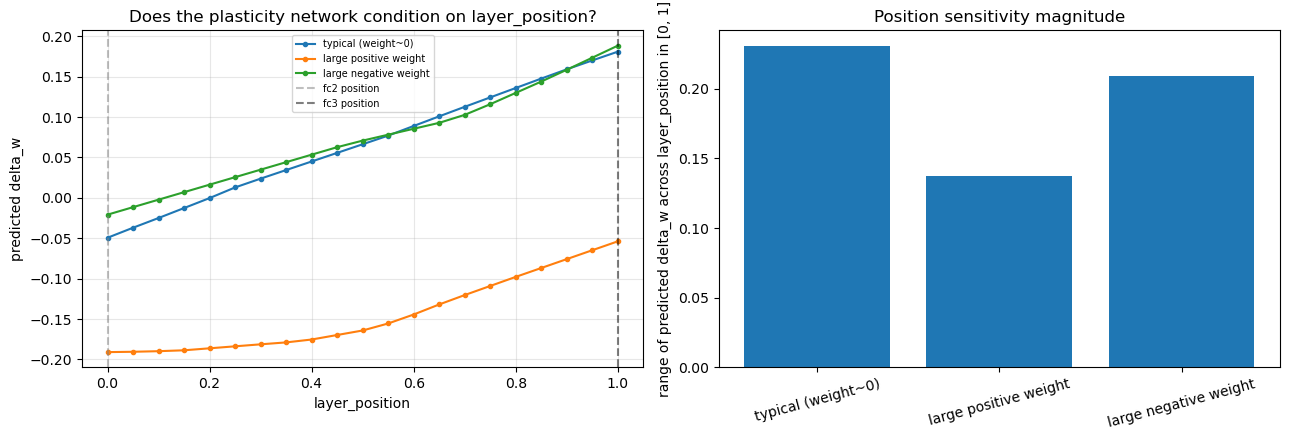

Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/position_sensitivity.png
Predicted delta_w range across layer_position in [0, 1] per representative feature:
  typical (weight~0): 0.23030
  large positive weight: 0.13711
  large negative weight: 0.20917


In [16]:
def position_sensitivity_scan(plasticity_net, num_points=21):
    positions = np.linspace(0, 1, num_points)
    representative_features = {
        "typical (weight~0)": [0.3, 0.3, 0.0, 0.1, 0.5, 0.5],
        "large positive weight": [0.3, 0.3, 1.5, 0.1, 0.5, 0.5],
        "large negative weight": [0.3, 0.3, -1.5, 0.1, 0.5, 0.5],
    }
    curves = {}
    plasticity_net.eval()
    with torch.no_grad():
        for label, base in representative_features.items():
            outputs = []
            for lp in positions:
                feat = torch.tensor([base + [lp]], dtype=torch.float32, device=device)
                outputs.append(plasticity_net(feat).item())
            curves[label] = np.array(outputs)
    return positions, curves


position_spread = {}

if condition_f_artifacts is not None:
    positions, curves = position_sensitivity_scan(condition_f_artifacts["plasticity_net"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for label, curve in curves.items():
        axes[0].plot(positions, curve, marker="o", markersize=3, label=label)
    axes[0].axvline(0.0, color="gray", linestyle="--", alpha=0.5, label="fc2 position")
    axes[0].axvline(1.0, color="black", linestyle="--", alpha=0.5, label="fc3 position")
    axes[0].set_xlabel("layer_position")
    axes[0].set_ylabel("predicted delta_w")
    axes[0].set_title("Does the plasticity network condition on layer_position?")
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.3)

    position_spread = {label: float(curve.max() - curve.min()) for label, curve in curves.items()}
    axes[1].bar(list(position_spread.keys()), list(position_spread.values()))
    axes[1].set_ylabel("range of predicted delta_w across layer_position in [0, 1]")
    axes[1].set_title("Position sensitivity magnitude")
    axes[1].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    position_sensitivity_path = os.path.join(LOCAL_OUTPUT_DIR, "position_sensitivity.png")
    plt.savefig(position_sensitivity_path, bbox_inches="tight", dpi=150)
    plt.show()

    print(f"Saved {position_sensitivity_path}")
    print("Predicted delta_w range across layer_position in [0, 1] per representative feature:")
    for label, spread in position_spread.items():
        print(f"  {label}: {spread:.5f}")
else:
    print("condition_f_artifacts is None -- Section 14 did not run for seed SEEDS[0]; skipping.")


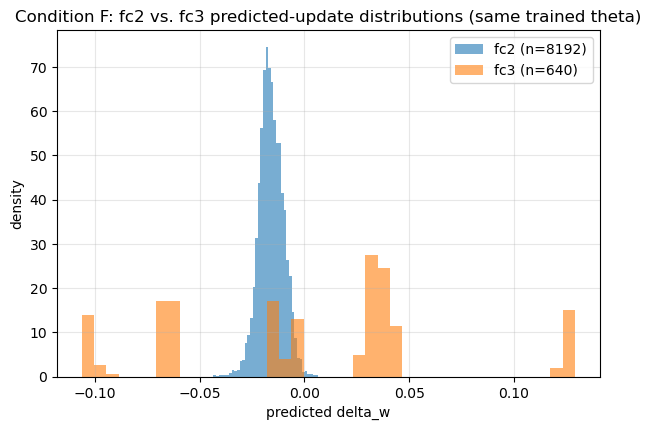

Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/layer_comparison.png
fc2: mean=-0.01588 std=0.00585 mean_abs=0.01590
fc3: mean=0.00105 std=0.06346 mean_abs=0.05245


In [17]:
def collect_final_update_distribution(artifacts, layer_specs_masks):
    model, plasticity_net = artifacts["model"], artifacts["plasticity_net"]
    layer_map, aux_projection = artifacts["layer_map"], artifacts["aux_projection"]

    x_batch, y_batch = next(iter(val_loader))
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    target_one_hot = F.one_hot(y_batch, num_classes=OUTPUT_DIM).float()

    errors, activations, _ = compute_local_errors(model, x_batch, target_one_hot, aux_projection)

    deltas = {}
    for name in ["fc2", "fc3"]:
        pre, post = activations[name]
        weight = layer_map[name].weight.detach()
        features, shape = build_synapse_features(
            pre.detach(), post.detach(), weight, errors[name].detach(),
            LAYER_POSITIONS[name], layer_specs_masks[name],
        )
        with torch.no_grad():
            delta_w = plasticity_net(features).view(*shape)
        deltas[name] = delta_w.cpu().numpy().flatten()

    return deltas


if condition_f_artifacts is not None:
    final_deltas = collect_final_update_distribution(
        condition_f_artifacts, {"fc2": WITH_LAYER_POSITION, "fc3": WITH_LAYER_POSITION}
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(final_deltas["fc2"], bins=40, alpha=0.6, label=f"fc2 (n={len(final_deltas['fc2'])})", density=True)
    ax.hist(final_deltas["fc3"], bins=40, alpha=0.6, label=f"fc3 (n={len(final_deltas['fc3'])})", density=True)
    ax.set_xlabel("predicted delta_w")
    ax.set_ylabel("density")
    ax.set_title("Condition F: fc2 vs. fc3 predicted-update distributions (same trained theta)")
    ax.legend()
    ax.grid(alpha=0.3)

    layer_comparison_path = os.path.join(LOCAL_OUTPUT_DIR, "layer_comparison.png")
    plt.savefig(layer_comparison_path, bbox_inches="tight", dpi=150)
    plt.show()

    print(f"Saved {layer_comparison_path}")
    for name, d in final_deltas.items():
        print(f"{name}: mean={d.mean():.5f} std={d.std():.5f} mean_abs={np.abs(d).mean():.5f}")
else:
    print("condition_f_artifacts is None -- skipping layer comparison.")


## 17. Learning Curves

All six conditions on shared axes, mean +/- std across seeds.

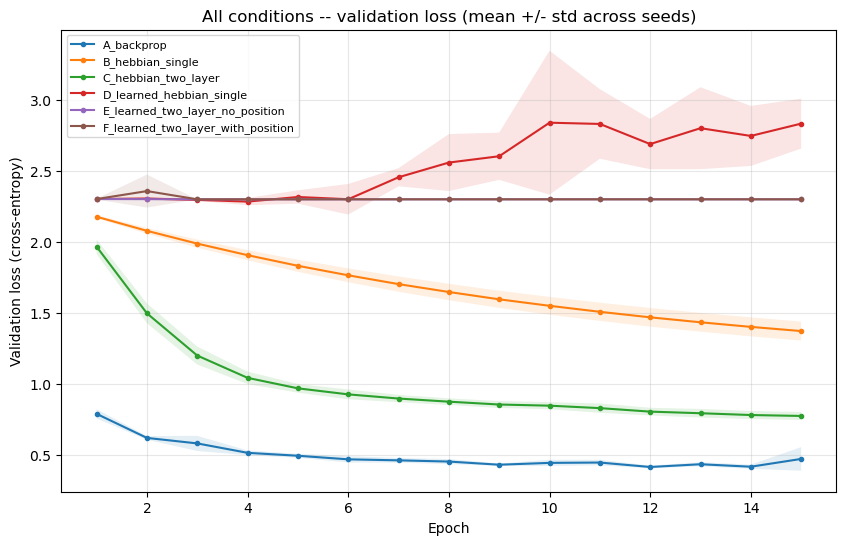

Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/training_curves.png


In [18]:
def plot_all_conditions(results, loss_key="val_loss_history"):
    fig, ax = plt.subplots(figsize=(10, 6))
    by_condition = {}
    for r in results:
        by_condition.setdefault(r["condition"], []).append(r[loss_key])

    for condition, curves in by_condition.items():
        curves = np.array(curves)
        mean = curves.mean(axis=0)
        std = curves.std(axis=0)
        epochs_axis = np.arange(1, len(mean) + 1)
        ax.plot(epochs_axis, mean, marker="o", markersize=3, label=condition)
        ax.fill_between(epochs_axis, mean - std, mean + std, alpha=0.12)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss (cross-entropy)")
    ax.set_title("All conditions -- validation loss (mean +/- std across seeds)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    return fig


fig = plot_all_conditions(all_results)
training_curves_path = os.path.join(LOCAL_OUTPUT_DIR, "training_curves.png")
fig.savefig(training_curves_path, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved {training_curves_path}")


## 18. Statistical Summary

Mean +/- std across seeds for every condition, including diagnostics (update magnitude, plasticity-network loss).

In [19]:
summary_rows = []
by_condition = {}
for r in all_results:
    by_condition.setdefault(r["condition"], []).append(r)

for condition, runs in by_condition.items():
    row = {
        "Condition": condition,
        "Method": runs[0]["method"],
        "Plastic layers": "+".join(runs[0]["plastic_layers"]) if runs[0]["plastic_layers"] else "-",
        "Seeds": len(runs),
        "Final val loss (mean)": np.mean([r["final_val_loss"] for r in runs]),
        "Final val loss (std)": np.std([r["final_val_loss"] for r in runs]),
        "Best val loss (mean)": np.mean([r["best_val_loss"] for r in runs]),
        "Test acc (mean)": np.mean([r["test_acc"] for r in runs]),
        "Test acc (std)": np.std([r["test_acc"] for r in runs]),
        "Avg train time (s)": np.mean([r["train_time_sec"] for r in runs]),
        "Plasticity params": runs[0]["plasticity_params"],
    }
    for layer_name in ["fc2", "fc3"]:
        vals = [r["diagnostics"][layer_name]["update_mean_abs"][-1]
                for r in runs if layer_name in r["diagnostics"]]
        if vals:
            row[f"{layer_name} final update |delta_w| (mean)"] = np.mean(vals)
        meta_vals = [r["diagnostics"][layer_name]["meta_loss"][-1]
                     for r in runs if layer_name in r["diagnostics"] and not np.isnan(r["diagnostics"][layer_name]["meta_loss"][-1])]
        if meta_vals:
            row[f"{layer_name} final plasticity-net loss (mean)"] = np.mean(meta_vals)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("Final val loss (mean)").reset_index(drop=True)

summary_csv_path = os.path.join(LOCAL_OUTPUT_DIR, "summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

print(f"Saved {summary_csv_path}")
summary_df


Saved /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position/summary.csv


,Condition,Method,Plastic layers,Seeds,Final val loss (mean),Final val loss (std),Best val loss (mean),Test acc (mean),Test acc (std),Avg train time (s),Plasticity params,fc3 final update |delta_w| (mean),fc2 final update |delta_w| (mean),fc3 final plasticity-net loss (mean),fc2 final plasticity-net loss (mean)
0,A_backprop,backprop,-,5,0.473253,0.083136,0.409069,0.8220,0.014100,9.092022,0,NaN,NaN,NaN,NaN
1,C_hebbian_two_layer,hebbian,fc2+fc3,5,0.776075,0.028294,0.774026,0.6992,0.013526,9.020792,0,0.019975,0.006820,NaN,NaN
2,B_hebbian_single,hebbian,fc3,5,1.374259,0.066778,1.374259,0.6158,0.017770,8.626755,0,0.023484,NaN,NaN,NaN
3,E_learned_two_layer_no_position,learned_hebbian,fc2+fc3,5,2.302585,0.000000,2.302585,0.0990,0.000000,12.994032,801,0.611004,0.591007,2.302585,2.302585
4,F_learned_two_layer_with_position,learned_hebbian,fc2+fc3,5,2.302585,0.000000,2.302585,0.0990,0.000000,13.042032,801,1.311094,0.939540,2.302585,2.302585
5,D_learned_hebbian_single,learned_hebbian,fc3,5,2.836121,0.175734,2.251844,0.1040,0.009675,10.528076,801,3.221182,NaN,2.236291,NaN


## 19. Research Question Answers

Generated directly from `summary_df` -- thresholds are seed-std-aware (a difference smaller than the combined standard deviation is reported as "not distinguishable from noise", not as a win).

In [20]:
def get_row(condition):
    return summary_df[summary_df["Condition"] == condition].iloc[0]


def compare(name_a, cond_a, name_b, cond_b, metric="Test acc (mean)", std_metric="Test acc (std)"):
    a, b = get_row(cond_a), get_row(cond_b)
    diff = a[metric] - b[metric]
    combined_std = ((a[std_metric] ** 2 + b[std_metric] ** 2) ** 0.5) if std_metric in a else 0.0
    distinguishable = abs(diff) > combined_std
    direction = f"{name_a} > {name_b}" if diff > 0 else f"{name_a} < {name_b}"
    verdict = direction if distinguishable else "not clearly distinguishable from seed noise"
    return diff, verdict, a[metric], b[metric]


report_lines = []

diff, verdict, a_val, b_val = compare("D (single-layer)", "D_learned_hebbian_single",
                                       "F (two-layer + position)", "F_learned_two_layer_with_position")
report_lines.append(
    f"RQ1 -- Does training multiple layers improve learned-Hebbian performance?\n"
    f"  D (fc3 only) test acc = {a_val:.3f}, F (fc2+fc3) test acc = {b_val:.3f} -> {verdict}."
)

diff, verdict, e_val, f_val = compare("E (no position)", "E_learned_two_layer_no_position",
                                       "F (with position)", "F_learned_two_layer_with_position")
report_lines.append(
    f"\nRQ2 -- Does layer_position help once it actually varies?\n"
    f"  E test acc = {e_val:.3f}, F test acc = {f_val:.3f} -> {verdict}."
)

if condition_f_artifacts is not None and position_spread:
    report_lines.append(
        f"\nRQ3 -- Can the shared network learn different behavior for early vs. late layers?\n"
        f"  Position-sensitivity scan (Section 16): predicted delta_w range across layer_position in "
        f"[0, 1] was {position_spread} (see position_sensitivity.png). "
        f"A near-zero range for all representative features means the network learned to ignore "
        f"layer_position; a nontrivial, consistent range means it didn't."
    )
else:
    report_lines.append(
        "\nRQ3 -- Can the shared network learn different behavior for early vs. late layers?\n"
        "  Position-sensitivity scan did not run (condition_f_artifacts unavailable) -- see Section 16."
    )

diff, verdict, hebbian_val, learned_val = compare("Conventional Hebbian (C, two-layer)", "C_hebbian_two_layer",
                                                    "Learned Hebbian (F, two-layer+position)", "F_learned_two_layer_with_position")
report_lines.append(
    f"\nRQ4 -- Does multi-layer learned Hebbian outperform conventional Hebbian?\n"
    f"  C (conventional) test acc = {hebbian_val:.3f}, F (learned) test acc = {learned_val:.3f} -> {verdict}."
)

report_lines.append(
    "\nRQ5 -- Does the method remain genuinely local?\n"
    "  Yes, by construction: every plastic layer has requires_grad=False for the entire run, "
    "the main-network update is a plain tensor write under torch.no_grad() (never loss.backward() "
    "on the main network), and the live assertion 'layer.weight.grad is None' ran after every "
    "single update in every condition without raising -- see Section 9 / 11."
)

fc2_std = weight_stats_df[(weight_stats_df["condition"] == "F_learned_two_layer_with_position") &
                           (weight_stats_df["layer"] == "fc2")]["final_weight_std"].mean()
fc2_std0 = weight_stats_df[(weight_stats_df["condition"] == "F_learned_two_layer_with_position") &
                            (weight_stats_df["layer"] == "fc2")]["initial_weight_std"].mean()
fc3_std = weight_stats_df[(weight_stats_df["condition"] == "F_learned_two_layer_with_position") &
                           (weight_stats_df["layer"] == "fc3")]["final_weight_std"].mean()
fc3_std0 = weight_stats_df[(weight_stats_df["condition"] == "F_learned_two_layer_with_position") &
                            (weight_stats_df["layer"] == "fc3")]["initial_weight_std"].mean()
collapse_detected = (fc2_std < 0.3 * fc2_std0) or (fc3_std < 0.3 * fc3_std0)
report_lines.append(
    f"\nRQ6 -- Does training multiple layers expose a failure mode in the one-step meta-objective?\n"
    f"  Condition F: fc2 weight_std {fc2_std0:.4f} -> {fc2_std:.4f}, "
    f"fc3 weight_std {fc3_std0:.4f} -> {fc3_std:.4f}.\n"
    f"  {'Weight-collapse pattern detected (std shrank by >70pct), consistent with the Phase 2 hypothesis.' if collapse_detected else 'No strong weight-collapse pattern detected in condition F.'}\n"
    f"  See the LR sensitivity scan (Section 14) for whether reducing plasticity_lr mitigates this."
)

research_answers = "\n".join(report_lines)
print(research_answers)

with open(os.path.join(LOCAL_OUTPUT_DIR, "research_question_answers.txt"), "w") as f:
    f.write(research_answers)


RQ1 -- Does training multiple layers improve learned-Hebbian performance?
  D (fc3 only) test acc = 0.104, F (fc2+fc3) test acc = 0.099 -> not clearly distinguishable from seed noise.

RQ2 -- Does layer_position help once it actually varies?
  E test acc = 0.099, F test acc = 0.099 -> not clearly distinguishable from seed noise.

RQ3 -- Can the shared network learn different behavior for early vs. late layers?
  Position-sensitivity scan (Section 16): predicted delta_w range across layer_position in [0, 1] was {'typical (weight~0)': 0.23029828816652298, 'large positive weight': 0.13711485266685486, 'large negative weight': 0.209168903529644} (see position_sensitivity.png). A near-zero range for all representative features means the network learned to ignore layer_position; a nontrivial, consistent range means it didn't.

RQ4 -- Does multi-layer learned Hebbian outperform conventional Hebbian?
  C (conventional) test acc = 0.699, F (learned) test acc = 0.099 -> Conventional Hebbian (C, 

## 20. Limitations

Carried forward from Phase 2, plus new ones specific to this notebook:

* **Synapse features are still batch-averaged** (Section 8) -- per-sample variation the plasticity
  network might exploit is discarded, same as Phase 2 and the original diffusion notebook's own
  Hebbian rule.
* **`fc2`'s local error is a random, untrained auxiliary projection** (Section 10) -- a real,
  literature-precedented locality-preserving choice, but its *quality* as a teaching signal is
  unverified and likely weak, especially with `fc1` also frozen-random. A weak `fc2` error signal
  would look identical, from the outside, to "position doesn't help" -- this notebook's diagnostics
  (Section 15/16) try to separate the two, but can't fully rule out the confound.
* **Simultaneous, not sequential, layer updates** (Section 9): both `fc2` and `fc3` compute their
  `delta_w` from the *same* pre-batch forward pass, applied "simultaneously" rather than `fc2`
  updating first and `fc3` then seeing the new `fc2`. This is a defensible, documented design
  choice (and directly addresses the research prompt's explicit concern about sequential-update
  mismatch by avoiding it), but it also means `fc3`'s lookahead in Section 9 always evaluates
  against a slightly stale `fc2`. A sequential-update variant is a natural next experiment.
* **Hyperparameters are unchanged from Phase 2, not retuned for two plastic layers** -- deliberate,
  for comparability, but two plastic layers roughly doubles how much the loss landscape can move
  per batch; the LR scan (Section 14) is the only systematic check of whether this matters, and it
  only varies `plasticity_lr`, not `meta_lr` or `hebbian_lr`.
* **Still only 2 of 3 layers are ever plastic** (`fc1` stays frozen throughout, per the prompt's
  own scoping) -- `layer_position` only takes two discrete values (0.0, 1.0), not a genuine
  continuum; a 3+ plastic-layer setup (or the 76-layer diffusion U-Net) is the real test of
  whether position generalizes smoothly.
* **This notebook doesn't repeat Phase 2's full 7-way feature ablation** in the two-layer setting
  (pre/post/weight/error individually) -- it focuses specifically on `layer_position` per the
  prompt's stated primary ablation. Re-running the full grid multi-layer is listed below.

## 21. Recommendation for Next Experiment

Computed from the actual results above, not decided in advance -- per Section 20 of the research prompt, the diffusion U-Net experiment should only follow if the evidence here is convincing.

In [21]:
f_row = get_row("F_learned_two_layer_with_position")
c_row = get_row("C_hebbian_two_layer")
b_row = get_row("B_hebbian_single")

learned_beats_conventional = f_row["Test acc (mean)"] > c_row["Test acc (mean)"] + c_row["Test acc (std)"]
learned_reasonably_functional = f_row["Test acc (mean)"] > 0.30  # well above chance (10 classes), well below backprop

print("=" * 70)
if learned_beats_conventional and learned_reasonably_functional:
    print("RECOMMENDATION: Evidence is promising enough to proceed toward the diffusion U-Net,")
    print("but only after re-running with the best LR-scan setting as the new default, and adding")
    print("a genuine 3rd plastic layer (or a proper multi-layer sequential-update variant) first --")
    print("the 76-conv-layer U-Net is a much larger jump than fc2/fc3, and this notebook's own")
    print("collapse diagnostics (Section 15) should be clean before committing that much compute.")
else:
    print("RECOMMENDATION: Do NOT proceed to the diffusion U-Net experiment yet.")
    print(f"Condition F (learned, two-layer, position-aware) test acc = {f_row['Test acc (mean)']:.3f}")
    print(f"Condition C (conventional Hebbian, two-layer) test acc      = {c_row['Test acc (mean)']:.3f}")
    print(f"Condition B (conventional Hebbian, single-layer) test acc   = {b_row['Test acc (mean)']:.3f}")
    print("The learned rule has not been shown to beat conventional Hebbian in this controlled")
    print("setting, so transferring it to a 76-conv-layer U-Net would spend a lot of compute on a")
    print("mechanism that hasn't yet demonstrated it works.")
print("=" * 70)
print()
print("Concrete next experiments, in priority order:")
print("  1. Re-run condition F using the LR-scan's best plasticity_lr as default (Section 14),")
print("     since the collapse hypothesis (Section 2, RQ6) is the leading suspect for the failure.")
print("  2. Replace fc2's random auxiliary-projection error (Section 10) with a slightly stronger")
print("     but still-local proxy, e.g. a SMALL FIXED random feedback matrix applied to fc3's error")
print("     (direct feedback alignment) instead of an independent auxiliary classifier, and compare.")
print("  3. Try a sequential-update variant (fc2 updates, THEN fc3 sees the new fc2) to test the")
print("     simultaneous-vs-sequential concern flagged in Section 20 directly, rather than just")
print("     documenting it as a limitation.")
print("  4. Only after 1-3 show a learned rule that is stable AND competitive with conventional")
print("     Hebbian: extend to a 3rd plastic layer (fc1) before attempting the diffusion U-Net,")
print("     since fc1 -> fc2 -> fc3 gives a genuine 3-point position continuum to test RQ2/RQ3 on.")


RECOMMENDATION: Do NOT proceed to the diffusion U-Net experiment yet.
Condition F (learned, two-layer, position-aware) test acc = 0.099
Condition C (conventional Hebbian, two-layer) test acc      = 0.699
Condition B (conventional Hebbian, single-layer) test acc   = 0.616
The learned rule has not been shown to beat conventional Hebbian in this controlled
setting, so transferring it to a 76-conv-layer U-Net would spend a lot of compute on a
mechanism that hasn't yet demonstrated it works.

Concrete next experiments, in priority order:
  1. Re-run condition F using the LR-scan's best plasticity_lr as default (Section 14),
     since the collapse hypothesis (Section 2, RQ6) is the leading suspect for the failure.
  2. Replace fc2's random auxiliary-projection error (Section 10) with a slightly stronger
     but still-local proxy, e.g. a SMALL FIXED random feedback matrix applied to fc3's error
     (direct feedback alignment) instead of an independent auxiliary classifier, and compare.
  3

### Save Everything

In [22]:
config = {
    "dataset": DATASET, "n_train": N_TRAIN, "n_val": N_VAL, "n_test": N_TEST,
    "batch_size": BATCH_SIZE, "input_dim": INPUT_DIM, "hidden1": HIDDEN1, "hidden2": HIDDEN2,
    "output_dim": OUTPUT_DIM, "epochs": EPOCHS, "backprop_lr": BACKPROP_LR,
    "hebbian_lr": HEBBIAN_LR, "plasticity_lr": PLASTICITY_LR, "meta_lr": META_LR,
    "grad_clip_norm": GRAD_CLIP_NORM, "seeds": SEEDS, "data_split_seed": DATA_SPLIT_SEED,
    "layer_positions": LAYER_POSITIONS, "lr_scan_plasticity_lr": LR_SCAN_PLASTICITY_LR,
    "lr_scan_seeds": LR_SCAN_SEEDS, "device": device,
}

with open(os.path.join(LOCAL_OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

serializable_results = [{k: v for k, v in r.items()} for r in all_results]
with open(os.path.join(LOCAL_OUTPUT_DIR, "full_results.json"), "w") as f:
    json.dump(serializable_results, f, indent=2)

logger.records = serializable_results
logger.save(os.path.join(LOCAL_OUTPUT_DIR, "metrics_log.csv"))

print(f"Saved config.json, full_results.json, metrics_log.csv to {LOCAL_OUTPUT_DIR}")

if S3_BUCKET:
    import boto3
    s3 = boto3.client("s3")
    prefix = S3_PREFIX.rstrip("/")
    for fname in ["config.json", "full_results.json", "metrics_log.csv", "summary.csv",
                  "weight_statistics.csv", "update_statistics.csv", "research_question_answers.txt",
                  "training_curves.png", "update_distributions.png", "layer_comparison.png",
                  "position_sensitivity.png"]:
        local_path = os.path.join(LOCAL_OUTPUT_DIR, fname)
        if os.path.exists(local_path):
            key = f"{prefix}/{fname}"
            s3.upload_file(local_path, S3_BUCKET, key)
            print(f"Uploaded s3://{S3_BUCKET}/{key}")
else:
    print("S3_BUCKET is None -- skipping upload, all outputs remain local only.")


Saved config.json, full_results.json, metrics_log.csv to /mnt/custom-file-systems/s3/shared/outputs/Learned_Hebbian_Plasticity_Phase3_MultiLayer_Position
S3_BUCKET is None -- skipping upload, all outputs remain local only.
